<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2026-1/Laboratorios/Laboratorio_12_random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 12:  Bosques aleatorios



Los arboles de desicion se ajustan muy bien a los datos de entrenamiento, sin embargo no permiten generalización. El overfiting es la caracteristica mas importante. Para dar solucion, se propone el algoritmo de random foreset basado en dos caracteristicas:

# 1. Se enetrenan varios árboles con diferentes subconjuntos del dataset original. Para ello se emplea bootstraping dentro de los datos del dataset inicial.


Dado un dataset con las siguientes caracteristicas:


|index|$y^{}$          |X1  |X2 |X3 |X4 |
|-|----------|-----|-----|-----|-----|
|1| |$y^{(1)}$ |$X_1^{1}$|$X_2^{1}$|$X_3^{1}$|$X_4^{1}$|
|2||$y^{(2)}$ |$X_1^{2}$|$X_2^{2}$|$X_3^{2}$|$X_4^{2}$|
|3||$y^{(3)}$ |$X_1^{3}$|$X_2^{3}$|$X_3^{3}$|$X_4^{3}$|
|4||$y^{(4)}$ |$X_1^{4}$|$X_2^{4}$|$X_3^{4}$|$X_4^{4}$|


Podemos definir como un hyperparametro el número de arboles, y también los datos que ingresan a cada árbol, para ello emplearemos la tecnica de [bootstraping](https://en.wikipedia.org/wiki/Bootstrapping_(statistics).


El botstrapping es una técnica de muestreo con reposición que se realiza para cada árbol, asi si se tienen 10 árboles, el muestre con reposicion  para los indices puede ser como sigue:
```

In: np.random.randint(0, 4, (10,4))

  
Out: array([[1, 0, 3, 3],
       [2, 1, 2, 0],
       [2, 3, 3, 3],
       [0, 2, 2, 3],
       [2, 0, 3, 3],
       [1, 1, 2, 0],
       [2, 2, 1, 2],
       [3, 0, 1, 0],
       [3, 1, 0, 2],
       [2, 0, 2, 0]])

```

Lo anterior quiere decir que el conjunto de datos del árbol 1, puede ser entrenado con las  X1, X2, X3, X4 con los datos de entrenamiento 2, 1, 2, 0


Cada fila del anterior array es usado como input para entrenar cada arbol, notese que los valores se puden repetir para entrenar el árbol i-esimo.


- Para cada nodo de todos los arboles se selecciona un número aleatorio de características, hasta cosntruir el árbol completo.


Al final se tendran un conjunto de arboles de desición sobre los cuales se aplicará agregación, es decir, cuando se pasa un nuevo dato de entrenamiento los arboles realizan la clasificación y se toma el valor elegido por la mayoria de los arboles



bagging = Agregation + bootstraping


Random forest permite seleccionar las caracteristicas más importantes


La estategia para optimizar los bosques pueden ser elegidos como sigue:

Fijar el numero de caracteristicas y el criterio de parada.

1. Determinar el error como función del número de árboles.

2. Definido el número de árboles y calculamos el error como función del numero de caracteristicas.

3. Con el numero de arboles fijo y el numero de caracteristicas, se optmiza el criterio de parada, (numero minimo de datos de una hoja)




REF: https://www.youtube.com/watch?v=3pa0vtW64Ic&ab_channel=CodificandoBits
https://en.wikipedia.org/wiki/Bootstrap_aggregating

ref: http://www.cs.cmu.edu/~qyj/papersA08/11-rfbook.pdf

ref : https://github.com/ageron/handson-ml2/blob/master/07_ensemble_learning_and_random_forests.ipynb


In [ ]:
#https://github.com/ageron/handson-ml2/blob/master/07_ensemble_learning_and_random_forests.ipynb

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=1000, n_features=4,
                           n_informative=2, n_redundant=0,
                           random_state=0, shuffle=False)

clf = RandomForestClassifier(max_depth=2, random_state=0)
clf.fit(X, y)

print(clf.predict([[0, 0, 0, 0]]))

[1]


Laboratorio:

1. Cargar load digitis
```
from sklearn.datasets import load_digits
digits = load_digits()
print(digits.data.shape)

import matplotlib.pyplot as plt
plt.gray()
plt.matshow(digits.images[95])
plt.show()
```

2. Aplicar random foreset usando sklearn para clasificar el dataset

(1797, 64)


<Figure size 432x288 with 0 Axes>

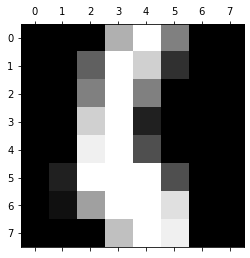

In [ ]:
from sklearn.datasets import load_digits
digits = load_digits()
print(digits.data.shape)

import matplotlib.pyplot as plt
plt.gray()
plt.matshow(digits.images[95])
plt.show()

PARTE 1: EJEMPLO INTRODUCTORIO DE RANDOM FOREST
Dimensiones del conjunto de datos: (1000, 4)
Numero de caracteristicas informativas: 2
Numero de caracteristicas redundantes: 0

Muestra de prueba: [0, 0, 0, 0]
Prediccion de la clase: 1

Numero de arboles en el bosque: 100
Profundidad maxima de cada arbol: 2
Numero de clases: 2

Importancia de las caracteristicas (ejemplo sintetico):
  Caracteristica 1: 0.1421
  Caracteristica 2: 0.7666
  Caracteristica 3: 0.0282
  Caracteristica 4: 0.0631



PARTE 2: LABORATORIO - RANDOM FOREST CON DIGITS DATASET
Dimensiones del dataset Digits: (1797, 64)
Numero de muestras: 1797
Numero de caracteristicas (pixeles): 64
Clases: [0 1 2 3 4 5 6 7 8 9]
Nombres de las clases: [0 1 2 3 4 5 6 7 8 9]


<Figure size 400x400 with 0 Axes>

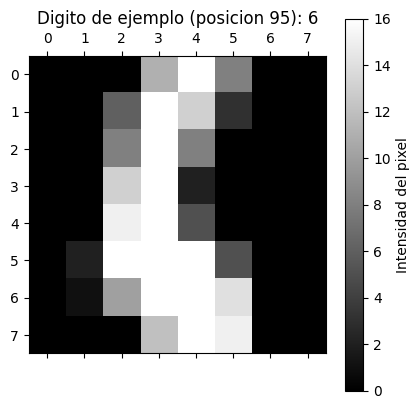

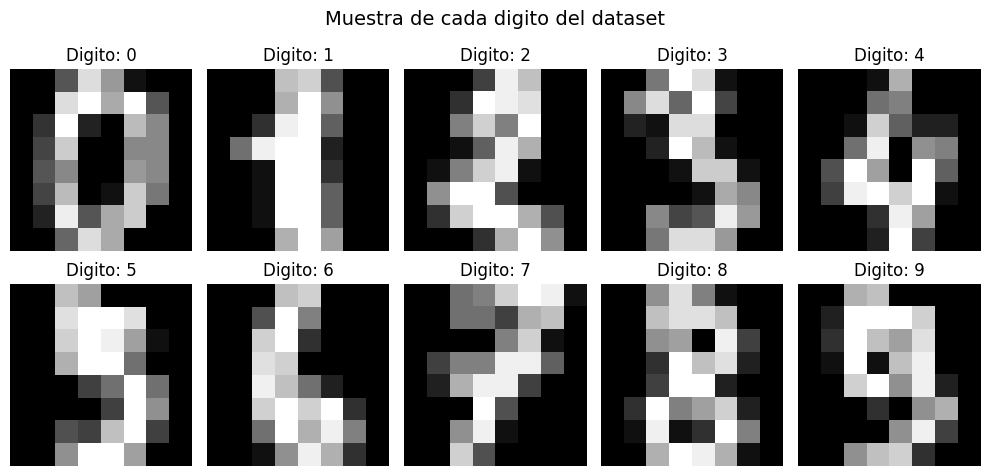


Tamaño del conjunto de entrenamiento: 1347 muestras
Tamaño del conjunto de prueba: 450 muestras
Proporcion entrenamiento/prueba: 75% / 25%

Entrenando el modelo Random Forest...
Entrenamiento completado.

RESULTADOS DE LA EVALUACION
Precision en entrenamiento: 1.0000 (100.00%)
Precision en prueba: 0.9667 (96.67%)

Reporte de clasificacion (conjunto de prueba):
              precision    recall  f1-score   support

           0       0.98      0.96      0.97        45
           1       0.94      0.96      0.95        46
           2       1.00      0.98      0.99        44
           3       0.96      1.00      0.98        46
           4       0.96      1.00      0.98        45
           5       0.98      0.98      0.98        46
           6       1.00      0.98      0.99        45
           7       0.94      1.00      0.97        45
           8       0.95      0.88      0.92        43
           9       0.98      0.93      0.95        45

    accuracy                           0

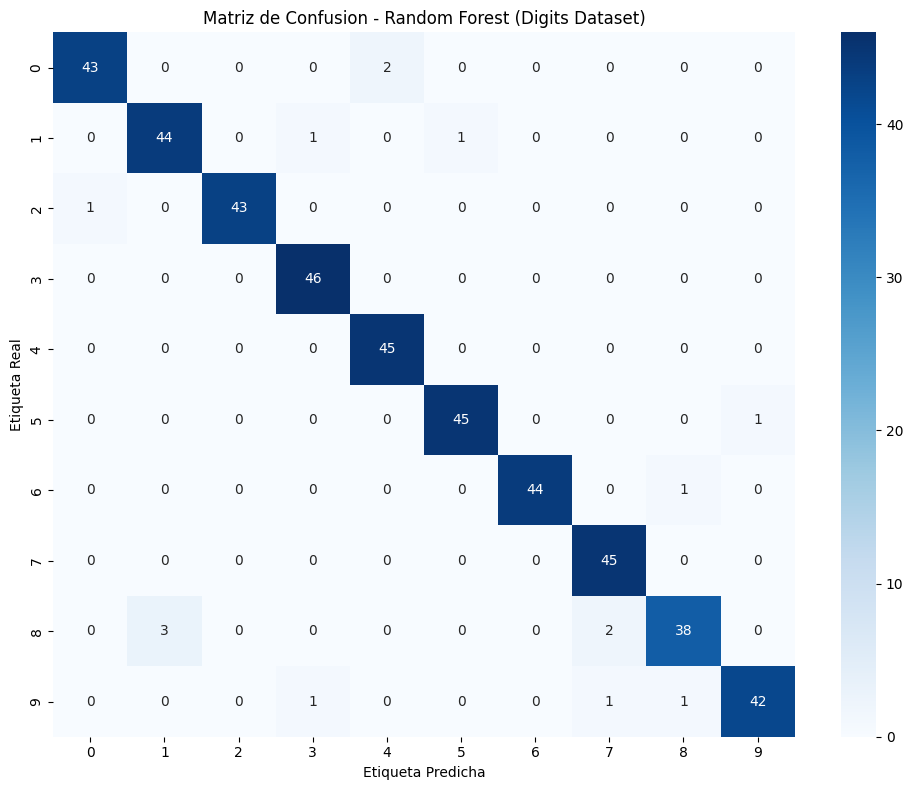

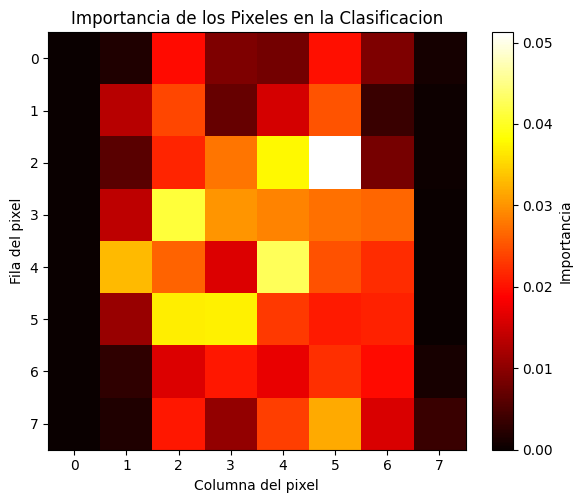

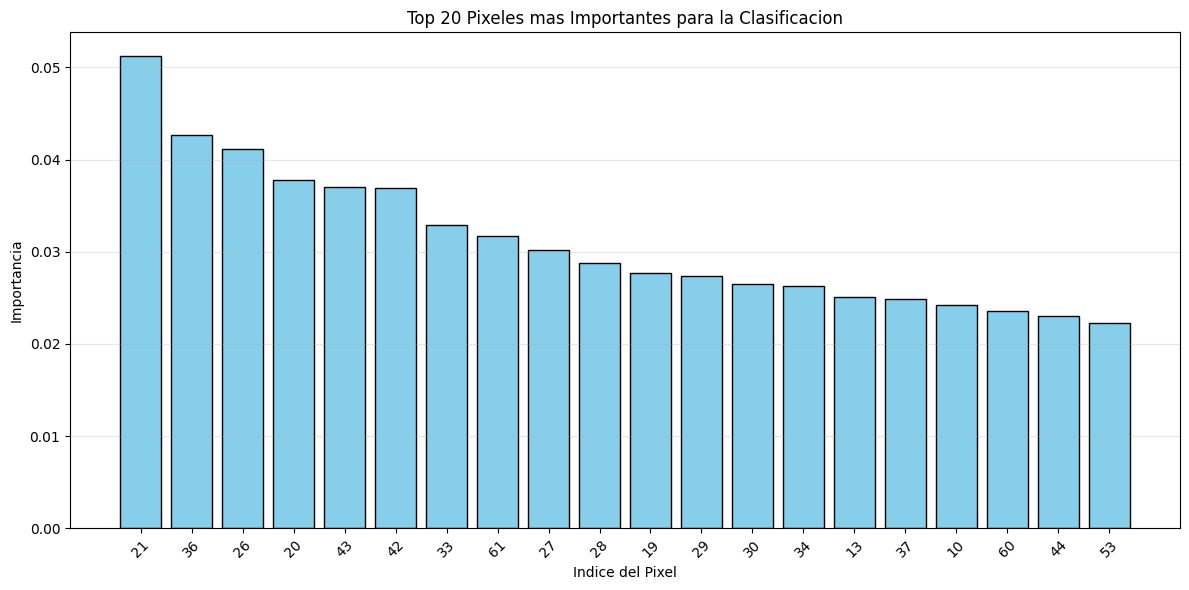


Analisis de errores:
Numero de predicciones incorrectas: 15


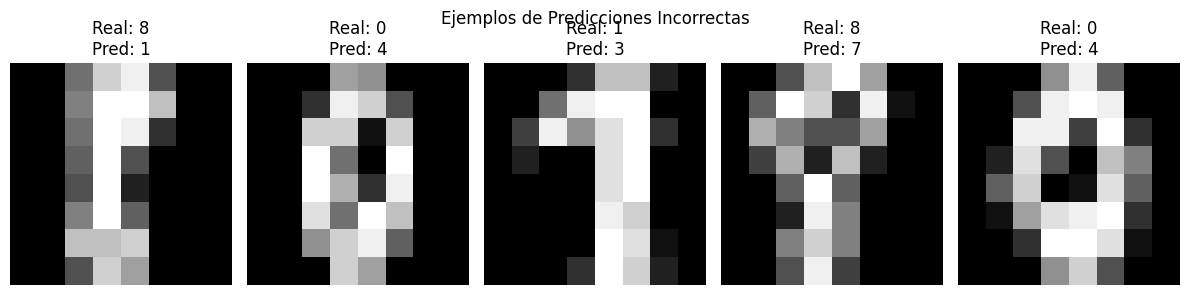


COMPARACION CON DIFERENTE NUMERO DE ARBOLES
Arboles:  10 | Precision entrenamiento: 0.9985 | Precision prueba: 0.9333
Arboles:  50 | Precision entrenamiento: 1.0000 | Precision prueba: 0.9600
Arboles: 100 | Precision entrenamiento: 1.0000 | Precision prueba: 0.9600
Arboles: 200 | Precision entrenamiento: 1.0000 | Precision prueba: 0.9667


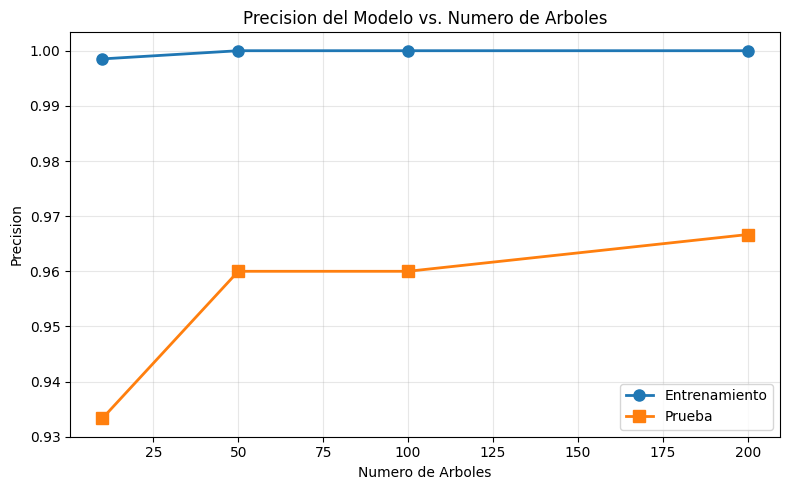


LABORATORIO COMPLETADO


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification, load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

# =============================================================================
# PARTE 1: EJEMPLO INTRODUCTORIO DE RANDOM FOREST
# =============================================================================

print("=" * 70)
print("PARTE 1: EJEMPLO INTRODUCTORIO DE RANDOM FOREST")
print("=" * 70)

# Generar datos sinteticos
X, y = make_classification(n_samples=1000, n_features=4,
                           n_informative=2, n_redundant=0,
                           random_state=0, shuffle=False)

print(f"Dimensiones del conjunto de datos: {X.shape}")
print(f"Numero de caracteristicas informativas: 2")
print(f"Numero de caracteristicas redundantes: 0")

# Crear y entrenar el clasificador Random Forest
clf = RandomForestClassifier(max_depth=2, random_state=0)
clf.fit(X, y)

# Realizar prediccion para una muestra de prueba
muestra_prueba = [[0, 0, 0, 0]]
prediccion = clf.predict(muestra_prueba)

print(f"\nMuestra de prueba: {muestra_prueba[0]}")
print(f"Prediccion de la clase: {prediccion[0]}")

# Informacion adicional del modelo entrenado
print(f"\nNumero de arboles en el bosque: {clf.n_estimators}")
print(f"Profundidad maxima de cada arbol: {clf.max_depth}")
print(f"Numero de clases: {clf.n_classes_}")

# Mostrar la importancia de las caracteristicas en el modelo sintetico
print("\nImportancia de las caracteristicas (ejemplo sintetico):")
for i, importancia in enumerate(clf.feature_importances_):
    print(f"  Caracteristica {i+1}: {importancia:.4f}")

# =============================================================================
# PARTE 2: LABORATORIO - RANDOM FOREST CON DIGITS DATASET
# =============================================================================

print("\n\n")
print("=" * 70)
print("PARTE 2: LABORATORIO - RANDOM FOREST CON DIGITS DATASET")
print("=" * 70)

# 1. Cargar el dataset Digits
digits = load_digits()
print(f"Dimensiones del dataset Digits: {digits.data.shape}")
print(f"Numero de muestras: {digits.data.shape[0]}")
print(f"Numero de caracteristicas (pixeles): {digits.data.shape[1]}")
print(f"Clases: {np.unique(digits.target)}")
print(f"Nombres de las clases: {digits.target_names}")

# Visualizar un digito de ejemplo (digito en la posicion 95)
plt.figure(figsize=(4, 4))
plt.gray()
plt.matshow(digits.images[95])
plt.title(f"Digito de ejemplo (posicion 95): {digits.target[95]}")
plt.colorbar(label='Intensidad del pixel')
plt.show()

# Visualizar varios digitos de ejemplo
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
axes = axes.ravel()
for i in range(10):
    # Encontrar el primer digito de cada clase
    idx = np.where(digits.target == i)[0][0]
    axes[i].imshow(digits.images[idx], cmap='gray')
    axes[i].set_title(f"Digito: {i}")
    axes[i].axis('off')
plt.suptitle("Muestra de cada digito del dataset", fontsize=14)
plt.tight_layout()
plt.show()

# 2. Aplicar Random Forest para clasificar el dataset
# -----------------------------------------------------------------------------
# Preparacion de los datos
X = digits.data
y = digits.target

# Division del dataset en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"\nTamaño del conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño del conjunto de prueba: {X_test.shape[0]} muestras")
print(f"Proporcion entrenamiento/prueba: 75% / 25%")

# Crear y entrenar el clasificador Random Forest
rf_clf = RandomForestClassifier(
    n_estimators=100,        # Numero de arboles en el bosque
    max_depth=10,            # Profundidad maxima de cada arbol
    min_samples_split=2,     # Numero minimo de muestras para dividir un nodo
    min_samples_leaf=1,      # Numero minimo de muestras en una hoja
    random_state=42,
    n_jobs=-1                # Usar todos los nucleos disponibles
)

print("\nEntrenando el modelo Random Forest...")
rf_clf.fit(X_train, y_train)
print("Entrenamiento completado.")

# Evaluacion del modelo
y_train_pred = rf_clf.predict(X_train)
y_test_pred = rf_clf.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("\n" + "=" * 50)
print("RESULTADOS DE LA EVALUACION")
print("=" * 50)
print(f"Precision en entrenamiento: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Precision en prueba: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Reporte detallado de clasificacion
print("\nReporte de clasificacion (conjunto de prueba):")
print(classification_report(y_test, y_test_pred, target_names=digits.target_names.astype(str)))

# Matriz de confusion
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=digits.target_names,
            yticklabels=digits.target_names)
plt.title('Matriz de Confusion - Random Forest (Digits Dataset)')
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Real')
plt.tight_layout()
plt.show()

# Importancia de las caracteristicas (pixeles)
# -----------------------------------------------------------------------------
# Visualizar la importancia de los pixeles como una imagen
importancia_pixeles = rf_clf.feature_importances_
importancia_imagen = importancia_pixeles.reshape(8, 8)

plt.figure(figsize=(6, 5))
plt.imshow(importancia_imagen, cmap='hot', interpolation='nearest')
plt.colorbar(label='Importancia')
plt.title('Importancia de los Pixeles en la Clasificacion')
plt.xlabel('Columna del pixel')
plt.ylabel('Fila del pixel')
plt.tight_layout()
plt.show()

# Grafico de barras con las 20 caracteristicas mas importantes
indices_importantes = np.argsort(importancia_pixeles)[::-1][:20]

plt.figure(figsize=(12, 6))
plt.bar(range(20), importancia_pixeles[indices_importantes], color='skyblue', edgecolor='black')
plt.xticks(range(20), indices_importantes, rotation=45)
plt.xlabel('Indice del Pixel')
plt.ylabel('Importancia')
plt.title('Top 20 Pixeles mas Importantes para la Clasificacion')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Analisis de errores: visualizar algunas predicciones incorrectas
print("\nAnalisis de errores:")
errores_idx = np.where(y_test_pred != y_test)[0]
print(f"Numero de predicciones incorrectas: {len(errores_idx)}")

if len(errores_idx) > 0:
    # Mostrar los primeros 5 errores
    n_errores_mostrar = min(5, len(errores_idx))
    fig, axes = plt.subplots(1, n_errores_mostrar, figsize=(12, 3))
    if n_errores_mostrar == 1:
        axes = [axes]

    for i, idx in enumerate(errores_idx[:n_errores_mostrar]):
        img_idx = np.where((digits.data == X_test[idx]).all(axis=1))[0]
        if len(img_idx) > 0:
            axes[i].imshow(digits.images[img_idx[0]], cmap='gray')
        else:
            axes[i].imshow(X_test[idx].reshape(8, 8), cmap='gray')
        axes[i].set_title(f"Real: {y_test[idx]}\nPred: {y_test_pred[idx]}")
        axes[i].axis('off')

    plt.suptitle('Ejemplos de Predicciones Incorrectas')
    plt.tight_layout()
    plt.show()

# Comparacion con diferentes numeros de arboles
print("\n" + "=" * 50)
print("COMPARACION CON DIFERENTE NUMERO DE ARBOLES")
print("=" * 50)

n_estimadores_lista = [10, 50, 100, 200]
resultados = []

for n_est in n_estimadores_lista:
    rf_temp = RandomForestClassifier(n_estimators=n_est, random_state=42, n_jobs=-1)
    rf_temp.fit(X_train, y_train)
    acc_train = accuracy_score(y_train, rf_temp.predict(X_train))
    acc_test = accuracy_score(y_test, rf_temp.predict(X_test))
    resultados.append((n_est, acc_train, acc_test))
    print(f"Arboles: {n_est:3d} | Precision entrenamiento: {acc_train:.4f} | Precision prueba: {acc_test:.4f}")

# Grafico comparativo
n_est_vals = [r[0] for r in resultados]
train_accs = [r[1] for r in resultados]
test_accs = [r[2] for r in resultados]

plt.figure(figsize=(8, 5))
plt.plot(n_est_vals, train_accs, 'o-', label='Entrenamiento', linewidth=2, markersize=8)
plt.plot(n_est_vals, test_accs, 's-', label='Prueba', linewidth=2, markersize=8)
plt.xlabel('Numero de Arboles')
plt.ylabel('Precision')
plt.title('Precision del Modelo vs. Numero de Arboles')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("LABORATORIO COMPLETADO")
print("=" * 70)